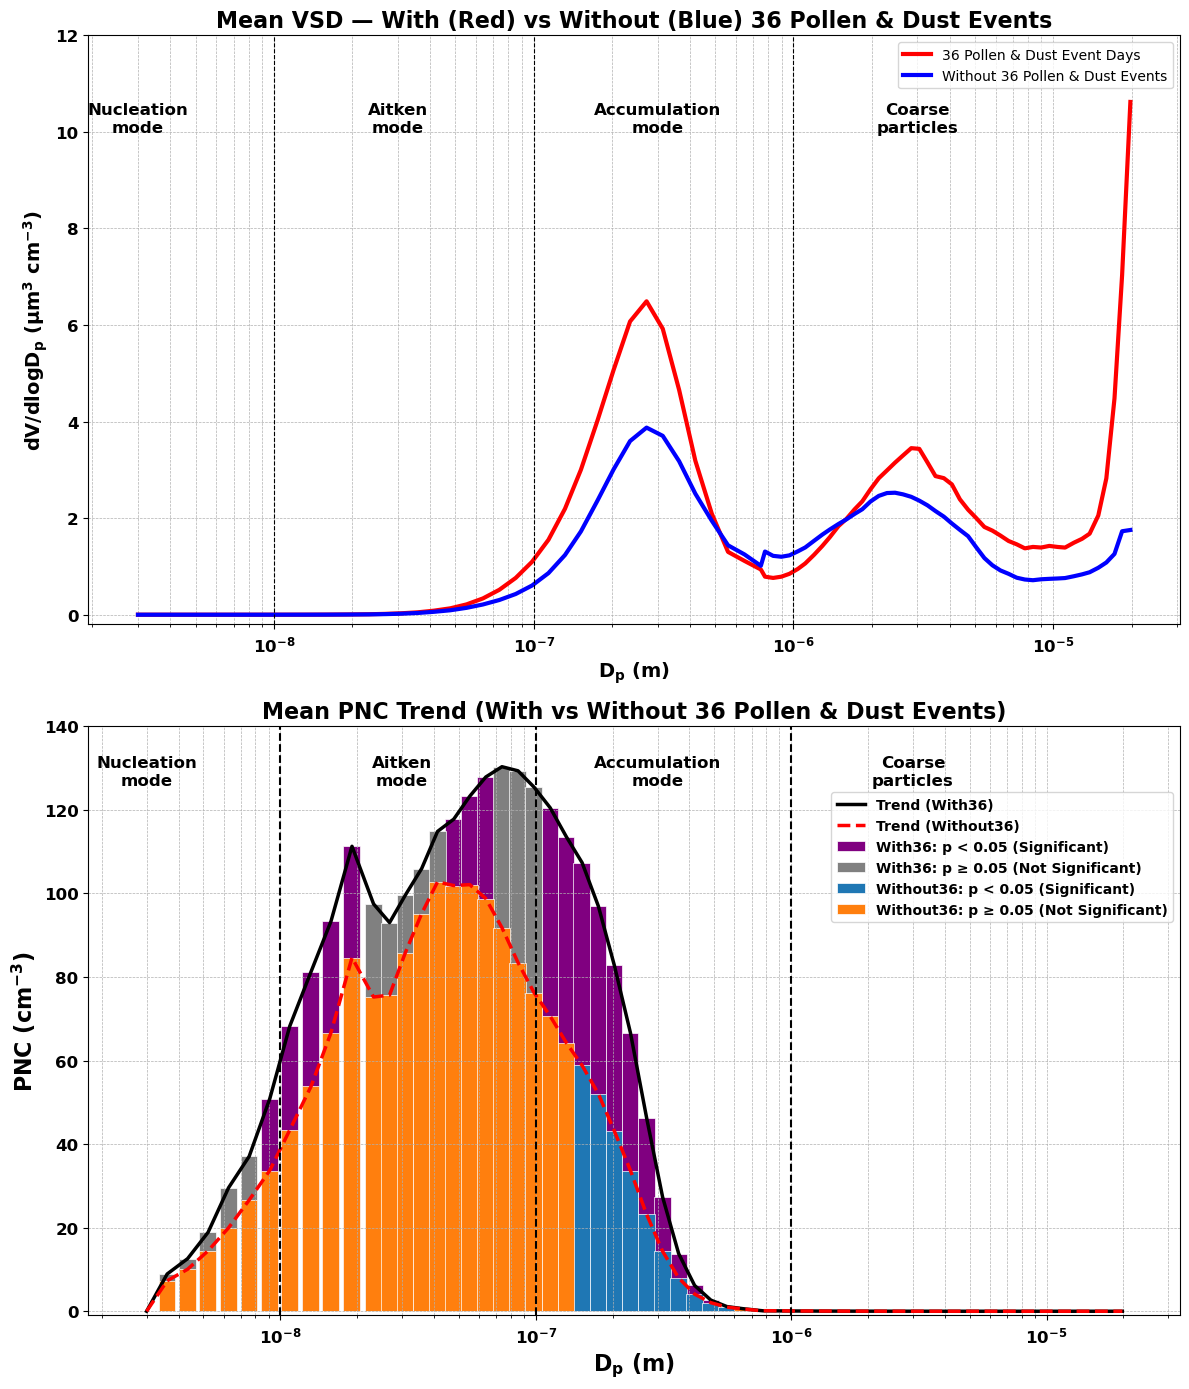

In [3]:
# ==== Import Packages ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, theilslopes, norm
from statsmodels.tsa.stattools import acf

# === File paths (unchanged) === #
with36_file_vsd = '/Users/touqeergill/Desktop/10. 36 Pollen and dust events.xlsx'
without36_file_vsd = '/Users/touqeergill/Desktop/10. Without 36 Pollen and dust events.xlsx'
file_with36 = '/Users/touqeergill/Desktop/10. PNC 36 Pollen and dust events.xlsx'
file_without36 = '/Users/touqeergill/Desktop/10. PNC Without 36 Pollen and dust events.xlsx'

# === Helper functions for PNC trend === #
def effective_sample_size(x, nlags=12):
    x = pd.Series(x).dropna()
    n = len(x)
    if n < 2 or np.all(x == x.iloc[0]):
        return 1
    try:
        acfs = acf(x, nlags=nlags, fft=True)[1:]
        ess = n / (1 + 2 * np.sum(acfs))
        return max(ess, 1)
    except Exception:
        return 1

def modified_mk_test(x, y):
    tau, _ = kendalltau(x, y)
    n_eff = effective_sample_size(y)
    z = tau * np.sqrt((9 * n_eff * (n_eff - 1)) / (2 * (2 * n_eff + 5)))
    p = 2 * (1 - norm.cdf(abs(z)))
    return tau, p

def process_file(file_path):
    df = pd.read_excel(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)

    resampled = df.resample('M').mean()
    resampled_low = df.resample('M').quantile(0.25)
    resampled_up = df.resample('M').quantile(0.75)

    x_dates = resampled.index
    x_num = (x_dates - x_dates[0]) / np.timedelta64(1, 'D')
    x_num = x_num.to_numpy()

    trend_stats = []
    for col in resampled.columns:
        y_main = resampled[col]
        y_low = resampled_low[col]
        y_up = resampled_up[col]

        mask = (~y_main.isna()) & (~y_low.isna()) & (~y_up.isna())
        if np.sum(mask) < 12:
            continue

        x_num_masked = x_num[mask]
        y_vals = y_main[mask].to_numpy(dtype='float64')

        try:
            tau, p_value = modified_mk_test(x_num_masked, y_vals)
            slope, intercept, slope_lo, slope_hi = theilslopes(y_vals, x_num_masked, alpha=0.95)
            slope_unc = (slope_hi - slope_lo) / 2
            mean_y = np.mean(y_vals)
            slope_yr = slope * 365.25
            slope_unc_yr = slope_unc * 365.25
            rel_trend = (slope_yr / abs(mean_y)) * 100 if mean_y != 0 else 0
            rel_unc = (slope_unc_yr / abs(mean_y)) * 100 if mean_y != 0 else 0

            trend_stats.append({
                'Bin': float(col),
                'PNC': mean_y,
                'Slope (unit/yr)': slope_yr,
                '± Slope Uncertainty': slope_unc_yr,
                'Relative Trend (%/yr)': rel_trend,
                '± Relative Uncertainty': rel_unc,
                'p-value': p_value
            })
        except Exception:
            continue

    return pd.DataFrame(trend_stats)

# === Load and process datasets === #
trend_df_with36 = process_file(file_with36)
trend_df_without36 = process_file(file_without36)

# ==== Extract data ====
particle_sizes = trend_df_with36['Bin'].to_numpy()
pnc_with36 = trend_df_with36['PNC'].to_numpy()
p_with36 = trend_df_with36['p-value'].to_numpy()
sig_with36 = p_with36 < 0.05
nonsig_with36 = ~sig_with36

pnc_without36 = trend_df_without36['PNC'].to_numpy()
p_without36 = trend_df_without36['p-value'].to_numpy()
sig_without36 = p_without36 < 0.05
nonsig_without36 = ~sig_without36

# === Colors for p-values === #
pval_colors = {
    'with_sig': '#800080',
    'with_nonsig': '#808080',
    'without_sig': '#1f77b4',
    'without_nonsig': '#ff7f0e'
}

# === Create combined figure === #
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# === TOP PLOT: Mean VSD (With vs Without 36 events) === #
df_no = pd.read_excel(without36_file_vsd)
df_ev = pd.read_excel(with36_file_vsd)

df_no['datetime'] = pd.to_datetime(df_no['datetime'])
df_ev['datetime'] = pd.to_datetime(df_ev['datetime'])

cols_no = df_no.columns[1:]
cols_ev = df_ev.columns[1:]
common_cols = [c for c in cols_no if c in set(cols_ev)]

diameters_m = np.array([float(c) for c in common_cols], dtype=float)
diameters_um = diameters_m * 1e6

volume_factors = (np.pi / 6.0) * (diameters_um ** 3)  # µm³ per particle
vol_no = df_no[common_cols].astype(float) * volume_factors
vol_ev = df_ev[common_cols].astype(float) * volume_factors

mean_no = vol_no.mean(numeric_only=True)
mean_ev = vol_ev.mean(numeric_only=True)

ax1.plot(diameters_m, mean_ev.values, color='red', linewidth=3, label='36 Pollen & Dust Event Days')
ax1.plot(diameters_m, mean_no.values, color='blue', linewidth=3, label='Without 36 Pollen & Dust Events')

ax1.set_xscale('log')
ax1.set_ylim(-0.2, 12)
ax1.set_xlabel(r'$\mathbf{D_p}$ (m)', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'$\mathbf{dV/dlogD_p\ (µm^3\ cm^{-3})}$', fontsize=14, fontweight='bold')
ax1.set_title('Mean VSD — With (Red) vs Without (Blue) 36 Pollen & Dust Events',
              fontsize=16, fontweight='bold')

for boundary in [1e-8, 1e-7, 1e-6]:
    ax1.axvline(x=boundary, color='k', linestyle='--', linewidth=0.8)

y_label_pos = 10
ax1.text(3e-9, y_label_pos, 'Nucleation\nmode', fontsize=12, ha='center', fontweight='bold')
ax1.text(3e-8, y_label_pos, 'Aitken\nmode', fontsize=12, ha='center', fontweight='bold')
ax1.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=12, ha='center', fontweight='bold')
ax1.text(3e-6, y_label_pos, 'Coarse\nparticles', fontsize=12, ha='center', fontweight='bold')

ax1.legend()
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontsize(12)
    tick.set_fontweight('bold')

# === BOTTOM PLOT: PNC Trends (With vs Without 36 events) === #
bar_width = particle_sizes * 0.15
ax2.bar(particle_sizes[sig_with36], pnc_with36[sig_with36],
        width=bar_width[sig_with36], color=pval_colors['with_sig'],
        edgecolor='white', linewidth=0.5, label='With36: p < 0.05 (Significant)')
ax2.bar(particle_sizes[nonsig_with36], pnc_with36[nonsig_with36],
        width=bar_width[nonsig_with36], color=pval_colors['with_nonsig'],
        edgecolor='white', linewidth=0.5, label='With36: p ≥ 0.05 (Not Significant)')
ax2.bar(particle_sizes[sig_without36], pnc_without36[sig_without36],
        width=bar_width[sig_without36], color=pval_colors['without_sig'],
        edgecolor='white', linewidth=0.5, label='Without36: p < 0.05 (Significant)')
ax2.bar(particle_sizes[nonsig_without36], pnc_without36[nonsig_without36],
        width=bar_width[nonsig_without36], color=pval_colors['without_nonsig'],
        edgecolor='white', linewidth=0.5, label='Without36: p ≥ 0.05 (Not Significant)')

ax2.plot(particle_sizes, pnc_with36, color='black', linewidth=2.5, label='Trend (With36)')
ax2.plot(particle_sizes, pnc_without36, color='red', linestyle='--', linewidth=2.5, label='Trend (Without36)')

ax2.set_xscale('log')
ax2.set_ylim(-1, 140)
ax2.set_xlabel(r'$\mathbf{D_p}$ (m)', fontsize=16, fontweight='bold')
ax2.set_ylabel(r'$\mathbf{PNC\ (cm^{-3})}$', fontsize=16)
ax2.set_title('Mean PNC Trend (With vs Without 36 Pollen & Dust Events)', fontsize=16, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

for boundary in [1e-8, 1e-7, 1e-6]:
    ax2.axvline(x=boundary, color='black', linestyle='--')

y_max_pnc = ax2.get_ylim()[1]
y_label_pos = y_max_pnc * 0.90
ax2.text(3e-9, y_label_pos, 'Nucleation\nmode', fontsize=12, fontweight='bold', ha='center')
ax2.text(3e-8, y_label_pos, 'Aitken\nmode', fontsize=12, fontweight='bold', ha='center')
ax2.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=12, fontweight='bold', ha='center')
ax2.text(3e-6, y_label_pos, 'Coarse\nparticles', fontsize=12, fontweight='bold', ha='center')

ax2.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 0.90), prop={'weight': 'bold'})
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontsize(12)
    tick.set_fontweight('bold')

# === Final Layout === #
plt.tight_layout()
plt.show()

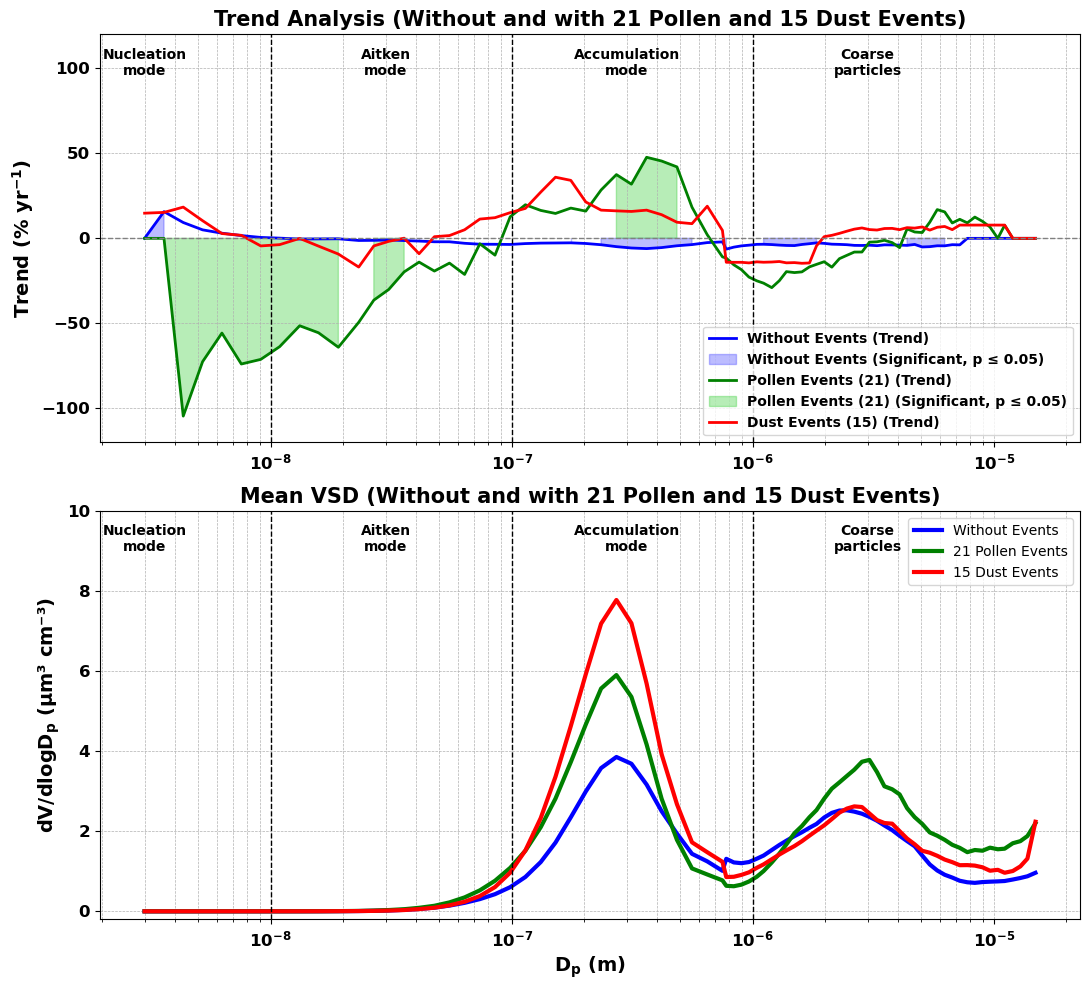


✅ Combined Trend + Mean VSD plot generated successfully (unified blue–green–red colors).


In [4]:
# ============================================================
# Combined Trend & Mean VSD Plot (Unified Colors)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# File Paths
# ------------------------------------------------------------
trend_files = {
    "Without Events": "/Users/touqeergill/Desktop/1. Volume_Distribution_dV_dlogDp (Without events).xlsx",
    "Pollen Events (21)": "/Users/touqeergill/Desktop/2. Volume_Distribution_dV_dlogDp_Pollen.xlsx",
    "Dust Events (15)": "/Users/touqeergill/Desktop/3. Volume_Distribution_dV_dlogDp_Dust.xlsx"
}

file_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_split    = '/Users/touqeergill/Desktop/DMPS_APS_pollen_dust_split.xlsx'

# ------------------------------------------------------------
# Unified Color Settings (same for both panels)
# ------------------------------------------------------------
colors = {
    "Without Events": "blue",
    "Pollen Events (21)": "green",
    "Dust Events (15)": "red"
}

# Matching fill colors (slightly lighter versions)
fill_colors = {
    "Without Events": "#4040ff",   # blue tone
    "Pollen Events (21)": "limegreen",
    "Dust Events (15)": "salmon"
}

# ------------------------------------------------------------
# Create Figure with Two Subplots
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=False)
plt.subplots_adjust(hspace=0.3)

# ============================================================
# (1) TREND PLOT (Top Panel)
# ============================================================
y_limits = (-120, 120)

for label, file_path in trend_files.items():
    df = pd.read_excel(file_path)
    particle_sizes = df['Bin (m)'].astype(float).to_numpy()
    trends = df['Relative Trend (%/yr)'].to_numpy()
    p_values = df['p-value'].to_numpy()

    # --- Trend line ---
    ax1.plot(
        particle_sizes,
        trends,
        color=colors[label],
        linewidth=2,
        label=f"{label} (Trend)"
    )

    # --- Significant bins (p < 0.05) ---
    significant = p_values < 0.05

    if label != "Dust Events (15)":
        ax1.fill_between(
            particle_sizes,
            0,
            trends,
            where=significant,
            color=fill_colors[label],
            alpha=0.35,
            label=f"{label} (Significant, p ≤ 0.05)"
        )
    else:
        ax1.fill_between(
            particle_sizes,
            0,
            trends,
            where=significant,
            color=fill_colors[label],
            alpha=0.35
        )

# --- Mode boundaries ---
mode_boundaries = [1e-8, 1e-7, 1e-6]
for boundary in mode_boundaries:
    ax1.axvline(x=boundary, color='black', linestyle='--', linewidth=1)

# --- Annotate modes ---
y_label_pos = 0.8 * y_limits[1]
ax1.text(3e-9, y_label_pos, 'Nucleation\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-8, y_label_pos, 'Aitken\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-6, y_label_pos, 'Coarse\nparticles', fontsize=10, ha='center', fontweight='bold')

# --- Formatting ---
ax1.set_xscale('log')
ax1.set_ylim(y_limits)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel(r'Trend (% yr$^{\mathbf{-1}}$)', fontsize=14, fontweight='bold')
ax1.set_title('Trend Analysis (Without and with 21 Pollen and 15 Dust Events)', fontsize=15, fontweight='bold')

ax1.legend(fontsize=9, loc='lower right', frameon=True, prop={'weight': 'bold'})
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.tick_params(axis='both', labelsize=12)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# (2) MEAN VSD PLOT (Bottom Panel)
# ============================================================
df_base   = pd.read_excel(file_baseline)
df_pollen = pd.read_excel(file_split, sheet_name='Pollen_Events')
df_dust   = pd.read_excel(file_split, sheet_name='Dust_Events')

for df in [df_base, df_pollen, df_dust]:
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')

cols_base   = df_base.columns[1:]
cols_pollen = df_pollen.columns[1:]
cols_dust   = df_dust.columns[1:]
common_cols = [c for c in cols_base if c in set(cols_pollen) and c in set(cols_dust)]
if not common_cols:
    raise ValueError("No common diameter columns found among datasets.")

diameters_m = np.array([float(c) for c in common_cols], dtype=float)
diameters_um = diameters_m * 1e6
volume_factors = (np.pi / 6.0) * (diameters_um ** 3)

vol_base   = df_base[common_cols].astype(float) * volume_factors
vol_pollen = df_pollen[common_cols].astype(float) * volume_factors
vol_dust   = df_dust[common_cols].astype(float) * volume_factors

mean_base   = vol_base.mean(numeric_only=True)
mean_pollen = vol_pollen.mean(numeric_only=True)
mean_dust   = vol_dust.mean(numeric_only=True)

# --- Plot Mean VSD ---
ax2.plot(diameters_m, mean_base.values,   color=colors["Without Events"], linewidth=3, label='Without Events')
ax2.plot(diameters_m, mean_pollen.values, color=colors["Pollen Events (21)"], linewidth=3, label='21 Pollen Events')
ax2.plot(diameters_m, mean_dust.values,   color=colors["Dust Events (15)"], linewidth=3, label='15 Dust Events')

ax2.set_xscale('log')
ax2.set_ylim(-0.2, 10)
ax2.set_xlabel(r'$\mathbf{D}_{\mathbf{p}}$ (m)', fontsize=14, fontweight='bold')
ax2.set_ylabel(r'dV/dlog$\mathbf{D}_{\mathbf{p}}$ (µm³ cm⁻³)', fontsize=14, fontweight='bold')
ax2.set_title('Mean VSD (Without and with 21 Pollen and 15 Dust Events)', fontsize=15, fontweight='bold')

# --- Mode boundaries ---
for boundary in mode_boundaries:
    ax2.axvline(x=boundary, color='black', linestyle='--', linewidth=1)

y_label_pos = 9
ax2.text(3e-9, y_label_pos, 'Nucleation\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-8, y_label_pos, 'Aitken\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-6, y_label_pos, 'Coarse\nparticles', fontsize=10, ha='center', fontweight='bold')

ax2.legend(fontsize=10, loc='upper right', frameon=True)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.tick_params(axis='both', labelsize=12)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# Final Touch
# ============================================================
plt.tight_layout()
plt.show()

print("\n✅ Combined Trend + Mean VSD plot generated successfully (unified blue–green–red colors).")

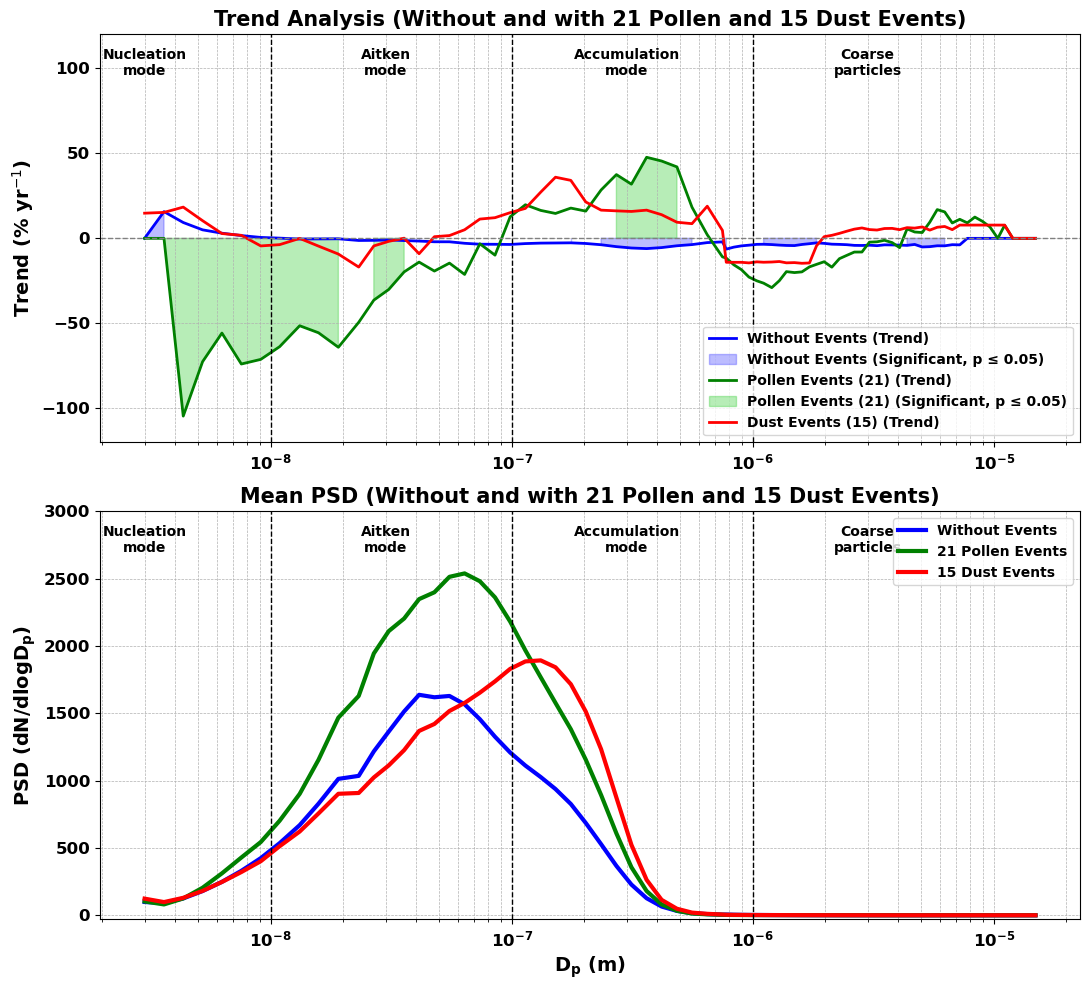


✅ Combined figure generated successfully (unified blue–green–red colors, Dust p-value legend removed).


In [5]:
# ============================================================
# Combined Figure: Trend Analysis (Top) + Mean PSD (Bottom)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ==== FILE PATHS ====
# ============================================================
trend_files = {
    "Without Events": "/Users/touqeergill/Desktop/1. Volume_Distribution_dV_dlogDp (Without events).xlsx",
    "Pollen Events (21)": "/Users/touqeergill/Desktop/2. Volume_Distribution_dV_dlogDp_Pollen.xlsx",
    "Dust Events (15)": "/Users/touqeergill/Desktop/3. Volume_Distribution_dV_dlogDp_Dust.xlsx"
}

file_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_pollen   = '/Users/touqeergill/Desktop/DMPS_APS_pollen.xlsx'
file_dust     = '/Users/touqeergill/Desktop/DMPS_APS_dust.xlsx'

# ============================================================
# ==== COLOR SETTINGS (Unified Blue–Green–Red) ====
# ============================================================
colors = {
    "Without Events": "blue",
    "Pollen Events (21)": "green",
    "Dust Events (15)": "red"
}

# Slightly lighter fill shades
fill_colors = {
    "Without Events": "#4040ff",   # blue tone
    "Pollen Events (21)": "limegreen",
    "Dust Events (15)": "salmon"
}

y_limits_trend = (-120, 120)

# ============================================================
# ==== LOAD PSD FILES FOR MEAN PSD (Bottom Plot)
# ============================================================
def load_and_process(file_path):
    """Load PSD file and compute monthly mean."""
    df = pd.read_excel(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df.set_index('datetime', inplace=True)
    df = df.resample('M').mean()
    return df

df_base   = load_and_process(file_baseline)
df_pollen = load_and_process(file_pollen)
df_dust   = load_and_process(file_dust)

# --- Common columns ---
common_cols = [c for c in df_base.columns if c in df_pollen.columns and c in df_dust.columns]
if len(common_cols) == 0:
    raise ValueError("No common diameter columns found among datasets.")

particle_sizes = np.array([float(c) for c in common_cols], dtype=float)

psd_base_mean   = df_base[common_cols].mean().to_numpy()
psd_pollen_mean = df_pollen[common_cols].mean().to_numpy()
psd_dust_mean   = df_dust[common_cols].mean().to_numpy()

# ============================================================
# ==== CREATE COMBINED FIGURE ====
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=False)
plt.subplots_adjust(hspace=0.35)

# ============================================================
# (A) TREND ANALYSIS PLOT (Top)
# ============================================================
for label, file_path in trend_files.items():
    df = pd.read_excel(file_path)
    particle_sizes_trend = df['Bin (m)'].astype(float).to_numpy()
    trends = df['Relative Trend (%/yr)'].to_numpy()
    p_values = df['p-value'].to_numpy()

    # --- Main trend line ---
    ax1.plot(particle_sizes_trend, trends, color=colors[label], linewidth=2, label=f"{label} (Trend)")

    # --- Fill significant bins ---
    significant = p_values < 0.05

    # Add legend entries only for "Without Events" and "Pollen"
    if label != "Dust Events (15)":
        ax1.fill_between(
            particle_sizes_trend,
            0,
            trends,
            where=significant,
            color=fill_colors[label],
            alpha=0.35,
            label=f"{label} (Significant, p ≤ 0.05)"
        )
    else:
        # Fill without legend for Dust
        ax1.fill_between(
            particle_sizes_trend,
            0,
            trends,
            where=significant,
            color=fill_colors[label],
            alpha=0.35
        )

# --- Mode boundaries ---
mode_boundaries = [1e-8, 1e-7, 1e-6]
for boundary in mode_boundaries:
    ax1.axvline(x=boundary, color='black', linestyle='--', linewidth=1)

# --- Annotate modes ---
y_label_pos = 0.8 * y_limits_trend[1]
ax1.text(3e-9, y_label_pos, 'Nucleation\nmode',   fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-8, y_label_pos, 'Aitken\nmode',       fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-6, y_label_pos, 'Coarse\nparticles',  fontsize=10, ha='center', fontweight='bold')

# --- Axis formatting ---
ax1.set_xscale('log')
ax1.set_ylim(y_limits_trend)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel(r'Trend (% yr$^{-1}$)', fontsize=14, fontweight='bold')
ax1.set_title('Trend Analysis (Without and with 21 Pollen and 15 Dust Events)', fontsize=15, fontweight='bold')

ax1.legend(fontsize=10, loc='lower right', frameon=True, prop={'weight': 'bold'})
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.tick_params(axis='both', labelsize=12)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# (B) MEAN PSD PLOT (Bottom)
# ============================================================
ax2.plot(particle_sizes, psd_base_mean,   color=colors["Without Events"], linewidth=3, label='Without Events')
ax2.plot(particle_sizes, psd_pollen_mean, color=colors["Pollen Events (21)"], linewidth=3, label='21 Pollen Events')
ax2.plot(particle_sizes, psd_dust_mean,   color=colors["Dust Events (15)"], linewidth=3, label='15 Dust Events')

ax2.set_xscale('log')
ax2.set_ylim(-30, 3000)
ax2.set_xlabel(r'$\mathbf{D}_{\mathbf{p}}$ (m)', fontsize=14, fontweight='bold')
ax2.set_ylabel(r'PSD (dN/dlog$\mathbf{D}_{\mathbf{p}}$)', fontsize=14, fontweight='bold')
ax2.set_title('Mean PSD (Without and with 21 Pollen and 15 Dust Events)', fontsize=15, fontweight='bold')

# --- Mode boundaries ---
for boundary in mode_boundaries:
    ax2.axvline(x=boundary, color='black', linestyle='--', linewidth=1)

# --- Annotate modes ---
y_label_pos2 = 2700
ax2.text(3e-9, y_label_pos2, 'Nucleation\nmode',   fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-8, y_label_pos2, 'Aitken\nmode',       fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-7, y_label_pos2, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-6, y_label_pos2, 'Coarse\nparticles',  fontsize=10, ha='center', fontweight='bold')

ax2.legend(fontsize=10, loc='upper right', frameon=True, prop={'weight': 'bold'})
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.tick_params(axis='both', labelsize=12)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# ==== FINAL TOUCH ====
# ============================================================
plt.tight_layout()
plt.show()

print("\n✅ Combined figure generated successfully (unified blue–green–red colors, Dust p-value legend removed).")


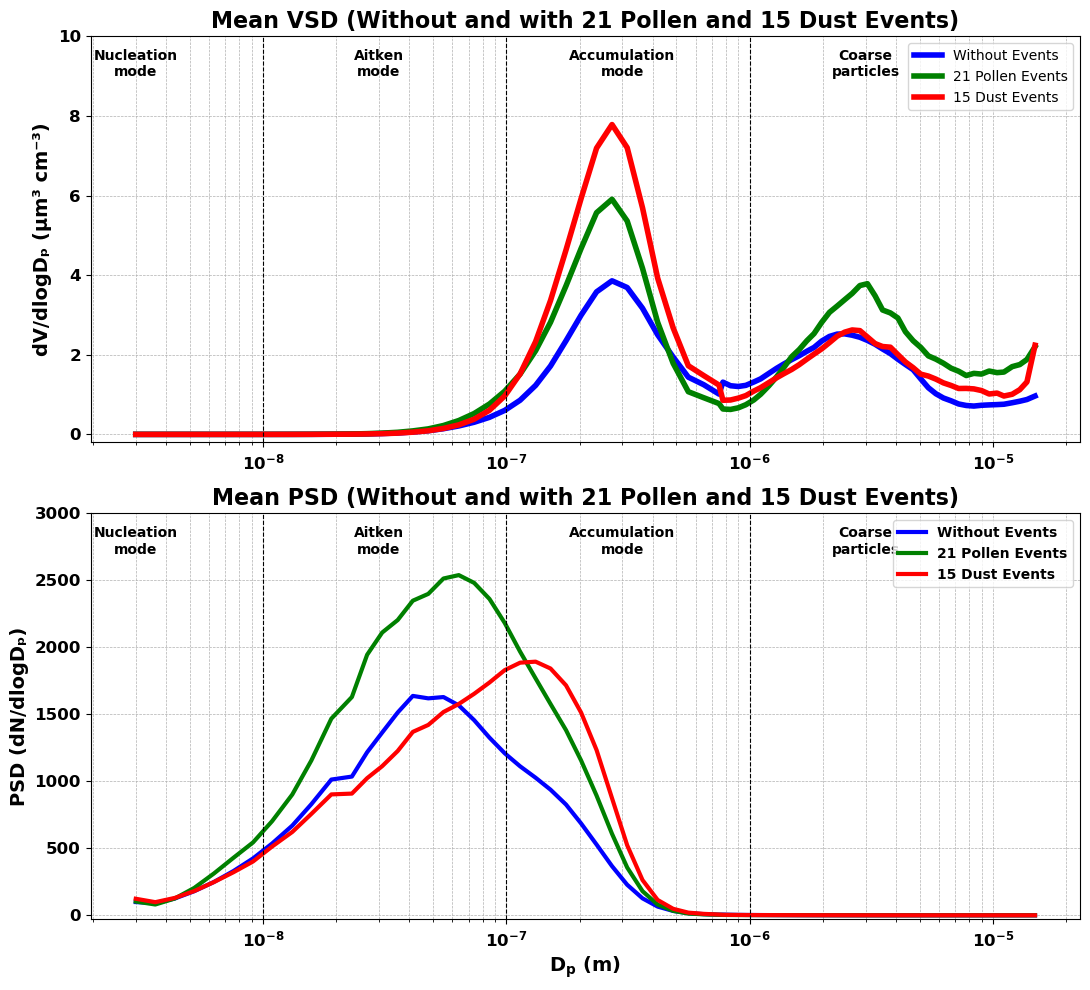


✅ Combined figure generated successfully: Mean VSD (top) + Mean PSD (bottom) with unified colors (blue–green–red).


In [6]:
# ============================================================
# Combined Figure: Mean VSD (Top) and Mean PSD (Bottom)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ==== FILE PATHS ====
# ============================================================
# --- For VSD ---
file_vsd_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_vsd_split    = '/Users/touqeergill/Desktop/DMPS_APS_pollen_dust_split.xlsx'

# --- For PSD ---
file_psd_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_psd_pollen   = '/Users/touqeergill/Desktop/DMPS_APS_pollen.xlsx'
file_psd_dust     = '/Users/touqeergill/Desktop/DMPS_APS_dust.xlsx'

# ============================================================
# ==== COLOR SETTINGS (Unified Blue–Green–Red) ====
# ============================================================
colors = {
    "Without Events": "blue",
    "Pollen Events (21)": "green",
    "Dust Events (15)": "red"
}

# ============================================================
# ==== LOAD AND PROCESS VSD DATA (Top Plot)
# ============================================================
df_base   = pd.read_excel(file_vsd_baseline)
df_pollen = pd.read_excel(file_vsd_split, sheet_name='Pollen_Events')
df_dust   = pd.read_excel(file_vsd_split, sheet_name='Dust_Events')

# Parse datetime
for df in [df_base, df_pollen, df_dust]:
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')

# Common diameter bins
cols_base   = df_base.columns[1:]
cols_pollen = df_pollen.columns[1:]
cols_dust   = df_dust.columns[1:]
common_cols = [c for c in cols_base if c in set(cols_pollen) and c in set(cols_dust)]
if not common_cols:
    raise ValueError("No common columns found among VSD datasets.")

diameters_m  = np.array([float(c) for c in common_cols], dtype=float)
diameters_um = diameters_m * 1e6

# Convert number to volume distribution
volume_factors = (np.pi / 6.0) * (diameters_um ** 3)
vol_base   = df_base[common_cols].astype(float) * volume_factors
vol_pollen = df_pollen[common_cols].astype(float) * volume_factors
vol_dust   = df_dust[common_cols].astype(float) * volume_factors

# Mean VSD
mean_base   = vol_base.mean(numeric_only=True)
mean_pollen = vol_pollen.mean(numeric_only=True)
mean_dust   = vol_dust.mean(numeric_only=True)

# ============================================================
# ==== LOAD AND PROCESS PSD DATA (Bottom Plot)
# ============================================================
def load_and_process(file_path):
    """Load PSD data, ensure datetime index, and compute monthly means."""
    df = pd.read_excel(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df.set_index('datetime', inplace=True)
    return df.resample('M').mean()

df_psd_base   = load_and_process(file_psd_baseline)
df_psd_pollen = load_and_process(file_psd_pollen)
df_psd_dust   = load_and_process(file_psd_dust)

common_cols_psd = [c for c in df_psd_base.columns if c in df_psd_pollen.columns and c in df_psd_dust.columns]
if not common_cols_psd:
    raise ValueError("No common diameter columns found among PSD datasets.")

particle_sizes = np.array([float(c) for c in common_cols_psd], dtype=float)

psd_base_mean   = df_psd_base[common_cols_psd].mean().to_numpy()
psd_pollen_mean = df_psd_pollen[common_cols_psd].mean().to_numpy()
psd_dust_mean   = df_psd_dust[common_cols_psd].mean().to_numpy()

# ============================================================
# ==== CREATE COMBINED FIGURE ====
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=False)
plt.subplots_adjust(hspace=0.35)

# ============================================================
# (A) MEAN VSD (Top)
# ============================================================
ax1.plot(diameters_m, mean_base.values,   color=colors["Without Events"], linewidth=4, label='Without Events')
ax1.plot(diameters_m, mean_pollen.values, color=colors["Pollen Events (21)"], linewidth=4, label='21 Pollen Events')
ax1.plot(diameters_m, mean_dust.values,   color=colors["Dust Events (15)"], linewidth=4, label='15 Dust Events')

ax1.set_xscale('log')
ax1.set_ylim(-0.2, 10)
ax1.set_ylabel('dV/dlogDₚ (µm³ cm⁻³)', fontsize=14, fontweight='bold')
ax1.set_title('Mean VSD (Without and with 21 Pollen and 15 Dust Events)', fontsize=16, fontweight='bold')

# Mode boundaries
for boundary in [1e-8, 1e-7, 1e-6]:
    ax1.axvline(x=boundary, color='black', linestyle='--', linewidth=0.8)

# Annotate particle modes
y_label_pos = 9
ax1.text(3e-9, y_label_pos, 'Nucleation\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-8, y_label_pos, 'Aitken\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-7, y_label_pos, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax1.text(3e-6, y_label_pos, 'Coarse\nparticles', fontsize=10, ha='center', fontweight='bold')

ax1.legend(fontsize=10, loc='upper right', frameon=True)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.tick_params(axis='both', labelsize=12)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# (B) MEAN PSD (Bottom)
# ============================================================
ax2.plot(particle_sizes, psd_base_mean,   color=colors["Without Events"], linewidth=3, label='Without Events')
ax2.plot(particle_sizes, psd_pollen_mean, color=colors["Pollen Events (21)"], linewidth=3, label='21 Pollen Events')
ax2.plot(particle_sizes, psd_dust_mean,   color=colors["Dust Events (15)"], linewidth=3, label='15 Dust Events')

ax2.set_xscale('log')
ax2.set_ylim(-30, 3000)
ax2.set_xlabel(r'$\mathbf{D}_{\mathbf{p}}$ (m)', fontsize=14, fontweight='bold')
ax2.set_ylabel('PSD (dN/dlogDₚ)', fontsize=14, fontweight='bold')
ax2.set_title('Mean PSD (Without and with 21 Pollen and 15 Dust Events)', fontsize=16, fontweight='bold')

# Mode boundaries and labels
for boundary in [1e-8, 1e-7, 1e-6]:
    ax2.axvline(x=boundary, color='black', linestyle='--', linewidth=0.8)

y_label_pos2 = 2700
ax2.text(3e-9, y_label_pos2, 'Nucleation\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-8, y_label_pos2, 'Aitken\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-7, y_label_pos2, 'Accumulation\nmode', fontsize=10, ha='center', fontweight='bold')
ax2.text(3e-6, y_label_pos2, 'Coarse\nparticles', fontsize=10, ha='center', fontweight='bold')

ax2.legend(fontsize=10, loc='upper right', frameon=True, prop={'weight': 'bold'})
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.tick_params(axis='both', labelsize=12)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')

# ============================================================
# ==== FINAL LAYOUT ====
# ============================================================
plt.tight_layout()
plt.show()

print("\n✅ Combined figure generated successfully: Mean VSD (top) + Mean PSD (bottom) with unified colors (blue–green–red).")


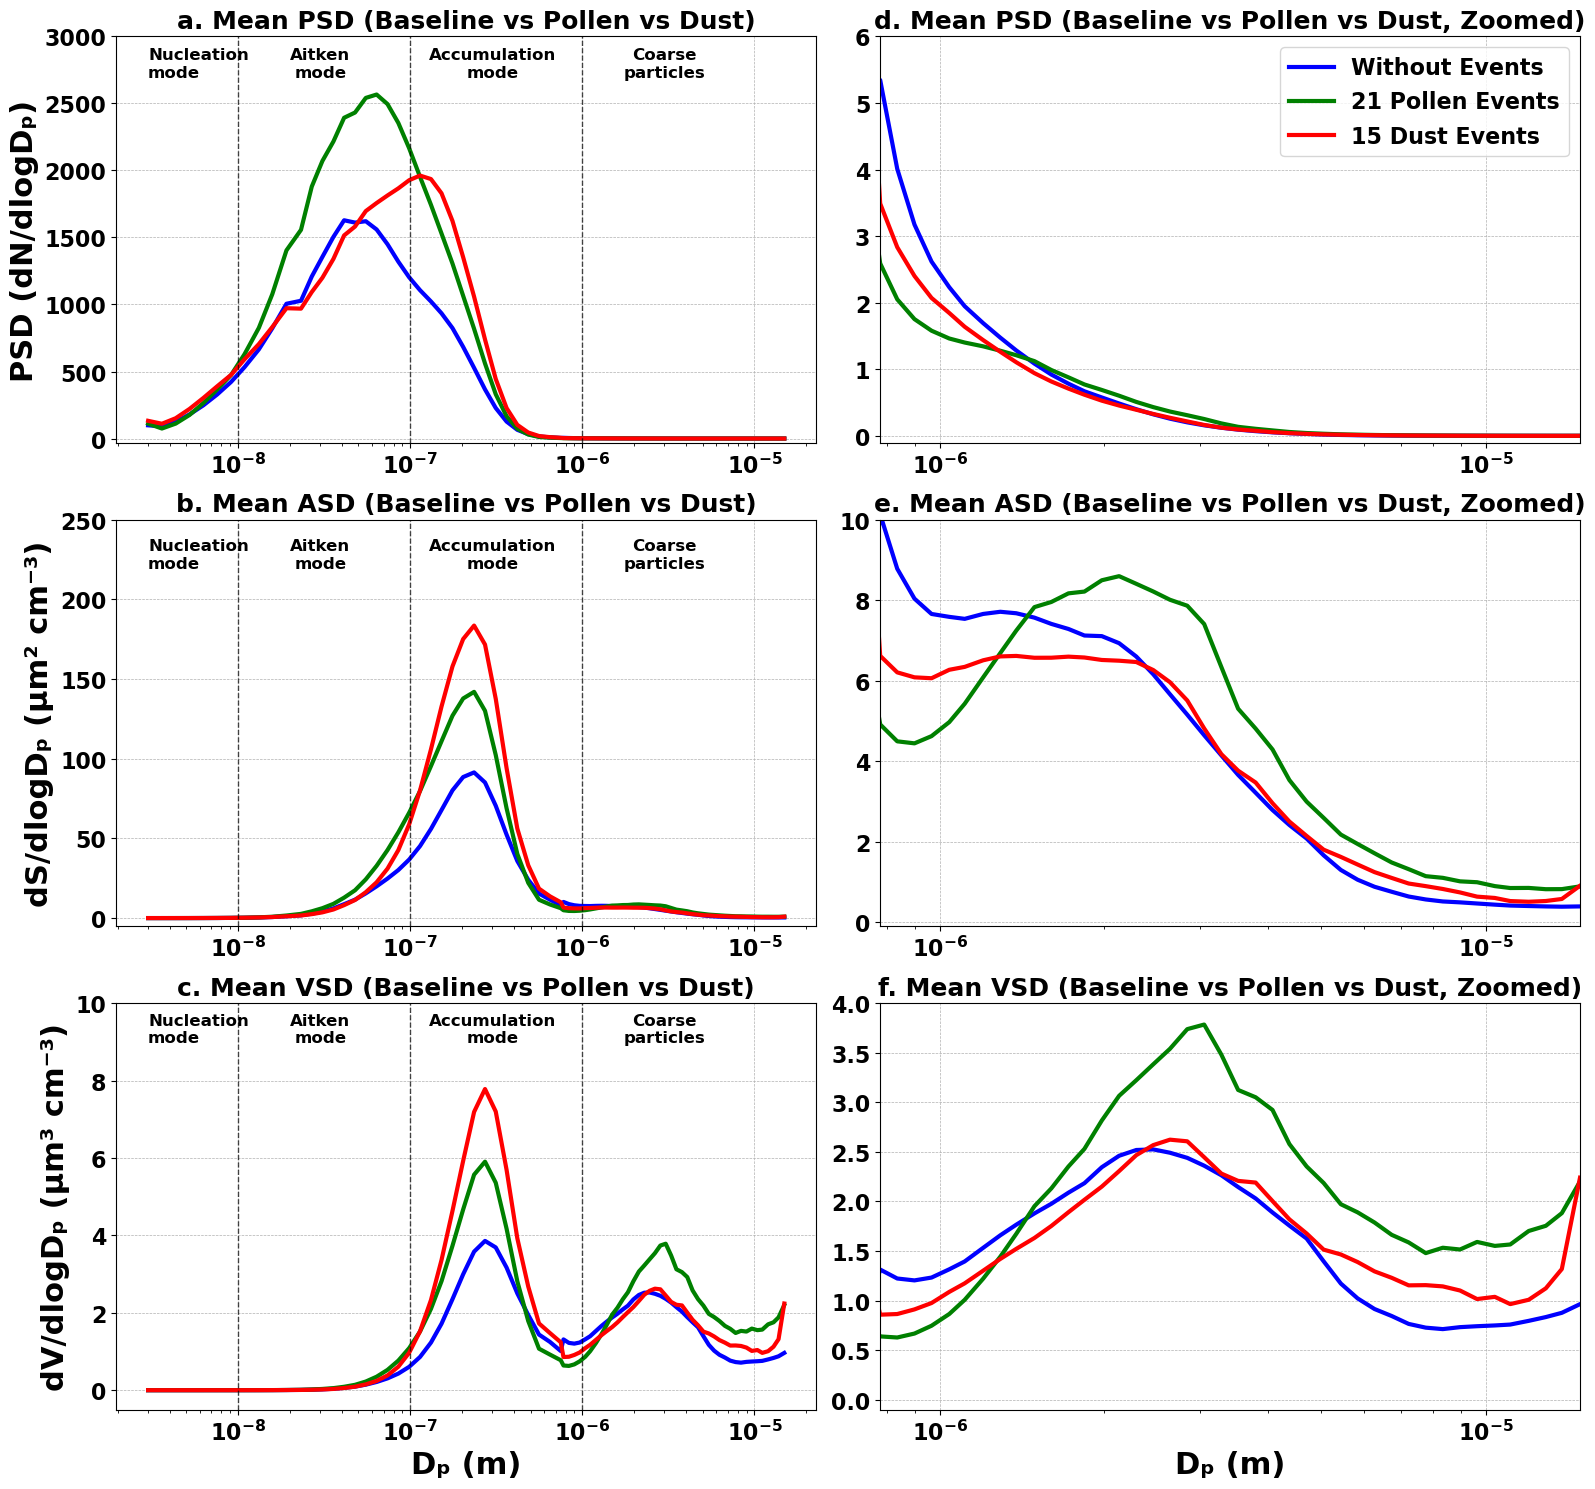


✅ Final figure with legend on right panel generated successfully!


In [7]:
# ============================================================
# Combined Figure: PSD + SAD + VSD (Full vs Zoom side-by-side)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# === FILE PATHS ===
# ============================================================
file_vsd_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_vsd_split    = '/Users/touqeergill/Desktop/DMPS_APS_pollen_dust_split.xlsx'

file_psd_baseline = '/Users/touqeergill/Desktop/DMPS_APS_baseline_data.xlsx'
file_psd_pollen   = '/Users/touqeergill/Desktop/DMPS_APS_pollen.xlsx'
file_psd_dust     = '/Users/touqeergill/Desktop/DMPS_APS_dust.xlsx'

# ============================================================
# ==== LOAD VSD DATA ====
# ============================================================
df_base_vsd   = pd.read_excel(file_vsd_baseline)
df_pollen_vsd = pd.read_excel(file_vsd_split, sheet_name='Pollen_Events')
df_dust_vsd   = pd.read_excel(file_vsd_split, sheet_name='Dust_Events')

for df in [df_base_vsd, df_pollen_vsd, df_dust_vsd]:
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')

cols_base   = df_base_vsd.columns[1:]
cols_pollen = df_pollen_vsd.columns[1:]
cols_dust   = df_dust_vsd.columns[1:]
common_cols_vsd = [c for c in cols_base if c in cols_pollen and c in cols_dust]

Dp_m_vsd  = np.array([float(c) for c in common_cols_vsd])
Dp_um_vsd = Dp_m_vsd * 1e6

volume_factors = (np.pi / 6.0) * (Dp_um_vsd ** 3)
mean_vsd_base   = (df_base_vsd[common_cols_vsd].astype(float) * volume_factors).mean()
mean_vsd_pollen = (df_pollen_vsd[common_cols_vsd].astype(float) * volume_factors).mean()
mean_vsd_dust   = (df_dust_vsd[common_cols_vsd].astype(float) * volume_factors).mean()

# ============================================================
# ==== LOAD PSD DATA ====
# ============================================================
def load_psd(file_path):
    df = pd.read_excel(file_path)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df.set_index("datetime", inplace=True)
    return df.resample("H").mean()

df_psd_base   = load_psd(file_psd_baseline)
df_psd_pollen = load_psd(file_psd_pollen)
df_psd_dust   = load_psd(file_psd_dust)

common_cols_psd = [c for c in df_psd_base.columns if c in df_psd_pollen.columns and c in df_psd_dust.columns]
Dp_m_psd = np.array([float(c) for c in common_cols_psd])

psd_base_mean   = df_psd_base[common_cols_psd].mean().to_numpy()
psd_pollen_mean = df_psd_pollen[common_cols_psd].mean().to_numpy()
psd_dust_mean   = df_psd_dust[common_cols_psd].mean().to_numpy()

# ============================================================
# ==== SAD DATA ====
# ============================================================
Dp_m_sad  = Dp_m_psd
Dp_um_sad = Dp_m_sad * 1e6

def compute_sad(df):
    dN = df[common_cols_psd].astype(float)
    dS = np.pi * (Dp_um_sad ** 2) * dN
    return dS.mean()

sad_base   = compute_sad(df_psd_base)
sad_pollen = compute_sad(df_psd_pollen)
sad_dust   = compute_sad(df_psd_dust)

# ============================================================
# ==== CREATE 3x2 FIGURE ====
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

xmin, xmax = 7.77e-7, 1.49e-5

(ax_psd_full, ax_psd_zoom), \
(ax_sad_full, ax_sad_zoom), \
(ax_vsd_full, ax_vsd_zoom) = axes

# ============================================================
# === PSD ===
# ============================================================
for ax in [ax_psd_full, ax_psd_zoom]:
    ax.plot(Dp_m_psd, psd_base_mean,   color="blue",  linewidth=3, label="Without Events")
    ax.plot(Dp_m_psd, psd_pollen_mean, color="green", linewidth=3, label="21 Pollen Events")
    ax.plot(Dp_m_psd, psd_dust_mean,   color="red",   linewidth=3, label="15 Dust Events")
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', linewidth=0.5)

# Full PSD
ax_psd_full.set_ylim(-30, 3000)
ax_psd_full.set_title("a. Mean PSD (Baseline vs Pollen vs Dust)", fontsize=18, fontweight='bold')

for b in [1e-8, 1e-7, 1e-6]:
    ax_psd_full.axvline(b, linestyle="--", color="black", linewidth=1, alpha=0.7)

ax_psd_full.text(3e-9, 2700, 'Nucleation\nmode', fontsize=12, ha='left', fontweight='bold')
ax_psd_full.text(3e-8, 2700, 'Aitken\nmode', fontsize=12, ha='center', fontweight='bold')
ax_psd_full.text(3e-7, 2700, 'Accumulation\nmode', fontsize=12, ha='center', fontweight='bold')
ax_psd_full.text(3e-6, 2700, 'Coarse\nparticles', fontsize=12, ha='center', fontweight='bold')

# Zoom PSD (legend here now)
ax_psd_zoom.set_xlim(xmin, xmax)
ax_psd_zoom.set_ylim(-0.1, 6)
ax_psd_zoom.set_title("d. Mean PSD (Baseline vs Pollen vs Dust, Zoomed)", fontsize=18, fontweight='bold')

legend = ax_psd_zoom.legend(fontsize=16, loc='upper right')
for text in legend.get_texts():
    text.set_fontweight('bold')

ax_psd_full.set_ylabel("PSD (dN/dlogDₚ)", fontsize=22, fontweight='bold')

# ============================================================
# === SAD ===
# ============================================================
for ax in [ax_sad_full, ax_sad_zoom]:
    ax.plot(Dp_m_sad, sad_base.values,   color="blue",  linewidth=3)
    ax.plot(Dp_m_sad, sad_pollen.values, color="green", linewidth=3)
    ax.plot(Dp_m_sad, sad_dust.values,   color="red",   linewidth=3)
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', linewidth=0.5)

ax_sad_full.set_ylim(-5, 250)
ax_sad_full.set_title("b. Mean ASD (Baseline vs Pollen vs Dust)", fontsize=18, fontweight='bold')

for b in [1e-8, 1e-7, 1e-6]:
    ax_sad_full.axvline(b, linestyle="--", color="black", linewidth=1, alpha=0.7)

ax_sad_full.text(3e-9, 220, 'Nucleation\nmode', fontsize=12, ha='left', fontweight='bold')
ax_sad_full.text(3e-8, 220, 'Aitken\nmode', fontsize=12, ha='center', fontweight='bold')
ax_sad_full.text(3e-7, 220, 'Accumulation\nmode', fontsize=12, ha='center', fontweight='bold')
ax_sad_full.text(3e-6, 220, 'Coarse\nparticles', fontsize=12, ha='center', fontweight='bold')

ax_sad_zoom.set_xlim(xmin, xmax)
ax_sad_zoom.set_ylim(-0.1, 10)
ax_sad_zoom.set_title("e. Mean ASD (Baseline vs Pollen vs Dust, Zoomed)", fontsize=18, fontweight='bold')

ax_sad_full.set_ylabel("dS/dlogDₚ (µm² cm⁻³)", fontsize=22, fontweight='bold')

# ============================================================
# === VSD ===
# ============================================================
for ax in [ax_vsd_full, ax_vsd_zoom]:
    ax.plot(Dp_m_vsd, mean_vsd_base.values,   color="blue",  linewidth=3)
    ax.plot(Dp_m_vsd, mean_vsd_pollen.values, color="green", linewidth=3)
    ax.plot(Dp_m_vsd, mean_vsd_dust.values,   color="red",   linewidth=3)
    ax.set_xscale("log")
    ax.grid(True, linestyle='--', linewidth=0.5)

ax_vsd_full.set_ylim(-0.5, 10)
ax_vsd_full.set_title("c. Mean VSD (Baseline vs Pollen vs Dust)", fontsize=18, fontweight='bold')

for b in [1e-8, 1e-7, 1e-6]:
    ax_vsd_full.axvline(b, linestyle="--", color="black", linewidth=1, alpha=0.7)

ax_vsd_full.text(3e-9, 9, 'Nucleation\nmode', fontsize=12, ha='left', fontweight='bold')
ax_vsd_full.text(3e-8, 9, 'Aitken\nmode', fontsize=12, ha='center', fontweight='bold')
ax_vsd_full.text(3e-7, 9, 'Accumulation\nmode', fontsize=12, ha='center', fontweight='bold')
ax_vsd_full.text(3e-6, 9, 'Coarse\nparticles', fontsize=12, ha='center', fontweight='bold')

ax_vsd_zoom.set_xlim(xmin, xmax)
ax_vsd_zoom.set_ylim(-0.1, 4)
ax_vsd_zoom.set_title("f. Mean VSD (Baseline vs Pollen vs Dust, Zoomed)", fontsize=18, fontweight='bold')

ax_vsd_full.set_ylabel("dV/dlogDₚ (µm³ cm⁻³)", fontsize=22, fontweight='bold')
ax_vsd_full.set_xlabel("Dₚ (m)", fontsize=22, fontweight='bold')
ax_vsd_zoom.set_xlabel("Dₚ (m)", fontsize=22, fontweight='bold')

# ============================================================
# FORMAT TICKS
# ============================================================
for row in axes:
    for ax in row:
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontsize(16)
            tick.set_fontweight('bold')

# ============================================================
# SHOW
# ============================================================
plt.tight_layout()
plt.show()

print("\n✅ Final figure with legend on right panel generated successfully!")